# Taller 4 - Análisis completo de un retailer online

## Materia:

- Métodos Estadísticos para Analisis de Datos

## Docente

- **Nombre**: Julian Hoyos

## Estudiantes

- Jose David Losada Legarda 76261004
- Yaneth Viviana Pechene Cuchumbe 76261010
- Darlyn Kamila Mamian Uni 76261009

### Pregunta que guía el análisis

¿Quiénes son los mejores clientes del retailer y qué productos conviene recomendarles o promocionar juntos para vender más?

Todo el notebook responde a esa pregunta. La limpieza prepara los datos, el análisis estadístico describe el negocio y valida la depuración, la segmentación identifica los tipos de cliente según su comportamiento, y las reglas de asociación indican qué productos empaquetar o recomendar. El cierre es un tablero que resume los hallazgos.

### Sobre el dataset

Transacciones de una tienda online del Reino Unido entre diciembre de 2010 y diciembre de 2011. Cada fila es un producto dentro de una factura, con su cantidad, precio, fecha, cliente y país. El análisis se concentra en el Reino Unido, que representa el 91% de las operaciones.

| Columna     | Descripción                                            |
| ----------- | ------------------------------------------------------ |
| InvoiceNo   | Número de factura. Si empieza con C es una cancelación |
| StockCode   | Código del producto                                    |
| Description | Nombre del producto                                    |
| Quantity    | Unidades compradas                                     |
| InvoiceDate | Fecha y hora de la operación                           |
| UnitPrice   | Precio unitario en libras                              |
| CustomerID  | Identificador del cliente                              |
| Country     | País del cliente                                       |


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import fpgrowth, association_rules
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

df = pd.read_excel("../data/external/Online_Retail.xlsx")
print(f"Dimensiones originales: {df.shape}")
df.head()


Dimensiones originales: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 1. Exploración inicial

Antes de limpiar conviene entender la estructura del dataset y dimensionar los problemas de calidad. Se revisan tipos, nulos, duplicados y valores imposibles.


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [3]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

print("Nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")
print(f"Cancelaciones (factura con C): {df['InvoiceNo'].str.startswith('C').sum()}")
print(f"Cantidades negativas o cero: {(df['Quantity'] <= 0).sum()}")
print(f"Precios negativos o cero: {(df['UnitPrice'] <= 0).sum()}")


Nulos por columna:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64



Filas duplicadas: 5268
Cancelaciones (factura con C): 9288
Cantidades negativas o cero: 10624
Precios negativos o cero: 2517


Los problemas detectados son varios y de distinta naturaleza.

Hay 135.080 filas sin `CustomerID`, una cuarta parte del total. Sin cliente identificado esas operaciones no sirven para segmentar, pero sí para analizar productos.

Aparecen 1.454 descripciones nulas, 5.268 duplicados exactos y unas 9.000 cancelaciones, que son devoluciones registradas como cantidades negativas.

También existen valores imposibles, cantidades y precios negativos o en cero, que son errores o ajustes administrativos.


## 2. Limpieza

Las decisiones se toman pensando en el objetivo. El interés está en compras reales de clientes del Reino Unido, así que se descarta todo lo que no represente una venta efectiva.


### Decisiones de limpieza

**Filtrar al Reino Unido.** Concentra el 91% de las ventas y evita mezclar mercados con volúmenes muy distintos.

**Eliminar duplicados.** Filas idénticas que inflan artificialmente los conteos.

**Eliminar cancelaciones.** Las facturas que empiezan con C son devoluciones, no ventas, y distorsionan el análisis de compra.

**Eliminar cantidades y precios no positivos.** Una venta real tiene cantidad y precio mayores a cero.

**Eliminar descripciones nulas.** Sin nombre de producto no se puede usar en el análisis de canasta.

**Conservar las filas sin `CustomerID`, pero separarlas.** Se mantienen para el análisis de productos y asociación, que no necesitan cliente, y se excluyen solo en la segmentación, que sí lo requiere. Así se aprovecha la mayor cantidad de datos en cada fase.

**Eliminar entradas que no son productos.** Códigos como `POSTAGE`, `MANUAL`, `BANK CHARGES` o los vales de regalo no son mercancía sino gastos o ajustes. Se reconocen porque su `StockCode` no tiene el formato de cinco dígitos de un producto, y se descartan para que no ensucien el análisis de canasta.

**Crear la columna `TotalPrice`.** El gasto de cada línea es la cantidad por el precio unitario, base de casi todas las métricas posteriores.


In [4]:
inicial = len(df)

df = df[df["Country"] == "United Kingdom"].copy()
df = df.drop_duplicates()
df = df[~df["InvoiceNo"].str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df = df.dropna(subset=["Description"])
# Conservar solo productos reales: el StockCode de un producto son 5 dígitos.
# Esto descarta POSTAGE, MANUAL, BANK CHARGES, vales de regalo y otros que no son mercancía.
df = df[df["StockCode"].astype(str).str.match(r"^\d{5}")]
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print(f"Filas iniciales: {inicial:,}")
print(f"Filas tras limpieza: {len(df):,}  ({len(df) / inicial * 100:.0f}% del total)")

# Dataset para segmentación, solo con cliente identificado
df_cli = df.dropna(subset=["CustomerID"]).copy()
df_cli["CustomerID"] = df_cli["CustomerID"].astype(int)
print(f"Filas con cliente (segmentación): {len(df_cli):,}")
print(f"Clientes únicos: {df_cli['CustomerID'].nunique():,}")
print(f"Facturas únicas: {df['InvoiceNo'].nunique():,}")
print(f"Productos únicos: {df['Description'].nunique():,}")

Filas iniciales: 541,909
Filas tras limpieza: 478,838  (88% del total)
Filas con cliente (segmentación): 348,872
Clientes únicos: 3,916
Facturas únicas: 17,901
Productos únicos: 3,986


### Verificación de redundancia entre variables

Igual que en otros datasets, conviene revisar si alguna variable numérica repite información de otra antes de seguir. Se mira la matriz de correlación entre las variables de cantidad, precio y gasto.


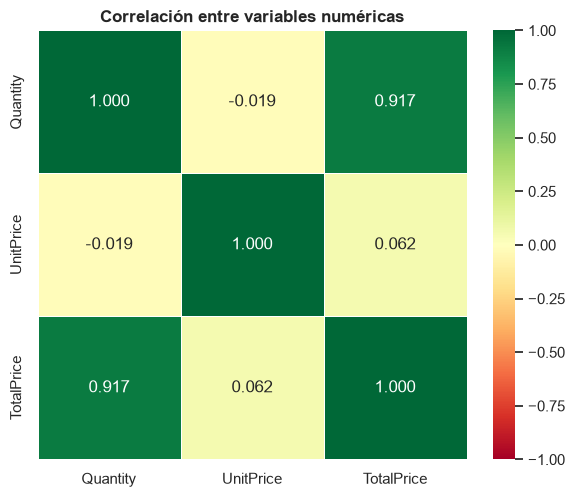

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    df[["Quantity", "UnitPrice", "TotalPrice"]].corr(),
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlación entre variables numéricas", fontweight="bold")
plt.tight_layout()
plt.show()


Hay un caso de dependencia esperable. `TotalPrice` correlaciona 0.91 con `Quantity`, porque se construye multiplicando cantidad por precio y la mayoría de los productos son baratos, así que el gasto sigue de cerca a la cantidad. Es una variable derivada, igual que `S4` lo era en el dataset de diabetes.

La diferencia es la decisión. Allá la variable derivada se eliminó por redundante. Aquí `TotalPrice` se conserva a propósito, porque es justamente la métrica de negocio que interesa, el dinero gastado, y es la base de casi todo el análisis posterior. La correlación alta no es un problema sino una consecuencia natural de cómo se define.

Por otro lado, `Quantity` y `UnitPrice` son independientes entre sí, con correlación cercana a cero, así que ninguna repite a la otra. No hay redundancia genuina que eliminar.


### Valores atípicos y balance del dataset

Antes de cerrar la limpieza conviene mirar los valores atípicos, porque en retail no siempre son errores. Una factura gigante puede ser un comprador mayorista real, y eliminarla borraría justo la parte más valiosa del negocio. Se analizan a nivel de factura con el criterio del rango intercuartílico, y se mide qué peso tienen en los ingresos.


Umbral de factura grande (IQR): £930
Facturas atípicas: 1,589 de 17,901 (8.9%)
Ingresos que representan: £3,986,018 (46% del total)
Factura más grande: £168,470  |  máximo de unidades: 80,995

Gini del gasto por cliente: 0.701  (0 = equilibrio total, 1 = máxima concentración)


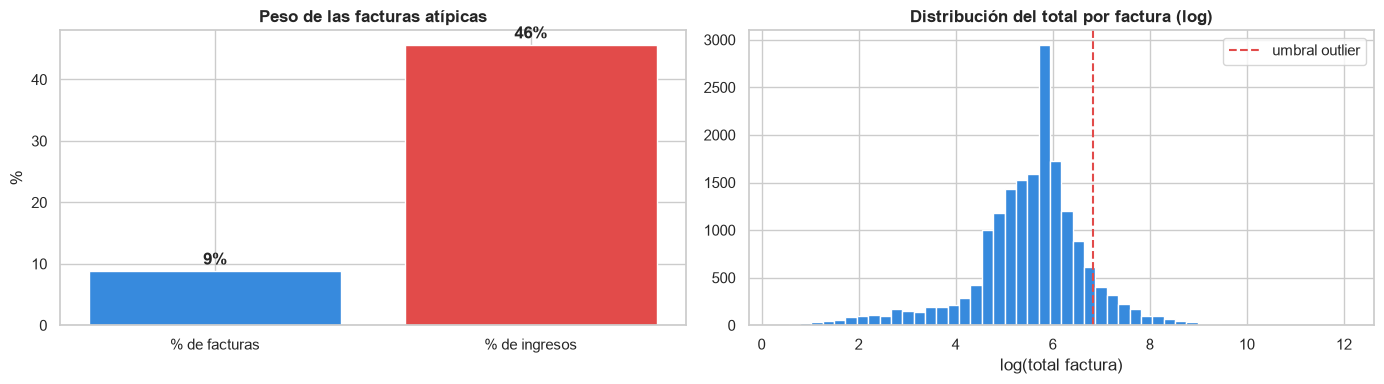

In [6]:
factura = df.groupby("InvoiceNo").agg(total=("TotalPrice", "sum"), unidades=("Quantity", "sum"))

q1, q3 = factura["total"].quantile([0.25, 0.75])
umbral = q3 + 1.5 * (q3 - q1)
outliers = factura[factura["total"] > umbral]

pct_facturas = len(outliers) / len(factura) * 100
pct_ingresos = outliers["total"].sum() / factura["total"].sum() * 100

print(f"Umbral de factura grande (IQR): £{umbral:.0f}")
print(f"Facturas atípicas: {len(outliers):,} de {len(factura):,} ({pct_facturas:.1f}%)")
print(f"Ingresos que representan: £{outliers['total'].sum():,.0f} ({pct_ingresos:.0f}% del total)")
print(
    f"Factura más grande: £{factura['total'].max():,.0f}  |  máximo de unidades: {factura['unidades'].max():,.0f}"
)


# Coeficiente de Gini para medir concentración (balance)
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - (n + 1) / n


gasto_cli = df.dropna(subset=["CustomerID"]).groupby("CustomerID")["TotalPrice"].sum()
print(
    f"\nGini del gasto por cliente: {gini(gasto_cli.values):.3f}  (0 = equilibrio total, 1 = máxima concentración)"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(
    ["% de facturas", "% de ingresos"], [pct_facturas, pct_ingresos], color=["#378ADD", "#E24B4A"]
)
for i, v in enumerate([pct_facturas, pct_ingresos]):
    axes[0].text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold")
axes[0].set_title("Peso de las facturas atípicas", fontweight="bold")
axes[0].set_ylabel("%")

axes[1].hist(np.log1p(factura["total"]), bins=50, color="#378ADD", edgecolor="white")
axes[1].axvline(np.log1p(umbral), color="#E24B4A", linestyle="--", label="umbral outlier")
axes[1].set_title("Distribución del total por factura (log)", fontweight="bold")
axes[1].set_xlabel("log(total factura)")
axes[1].legend()
plt.tight_layout()
plt.show()


El hallazgo es decisivo. Las facturas atípicas son apenas el 9% del total pero concentran el 46% de los ingresos, casi la mitad. No son errores, son compras de gran volumen, casi con seguridad de clientes mayoristas que revenden. El coeficiente de Gini de 0.70 confirma que el negocio está muy concentrado, lejos de un reparto equilibrado, una minoría de clientes y facturas sostiene la mayor parte de la facturación.

Por eso la decisión es conservar estos valores atípicos sin imputarlos ni recortarlos. Imputarlos destruiría casi la mitad de los ingresos y borraría el segmento más rentable. Lo que sí se hace es estudiarlos aparte, primero para ver cuándo ocurren en el análisis estadístico, y después para evaluarlos como nicho de mercado en la parte de algoritmos. La única cautela es usar escala logarítmica en las técnicas sensibles a la magnitud, para que estas compras enormes no aplasten al resto.

Sobre el balance, queda claro que el dataset no está equilibrado, sino fuertemente sesgado hacia pocos compradores grandes. Esto no es un defecto a corregir sino una característica del negocio que el análisis debe respetar.


### Diagrama de cajas de las variables

El diagrama de caja y bigotes es la forma clásica de ver los valores atípicos. La caja abarca el grueso de los datos y los puntos que quedan más allá de los bigotes son los atípicos. Como las variables están muy sesgadas, se grafican en escala logarítmica para que la caja no quede aplastada contra el eje.


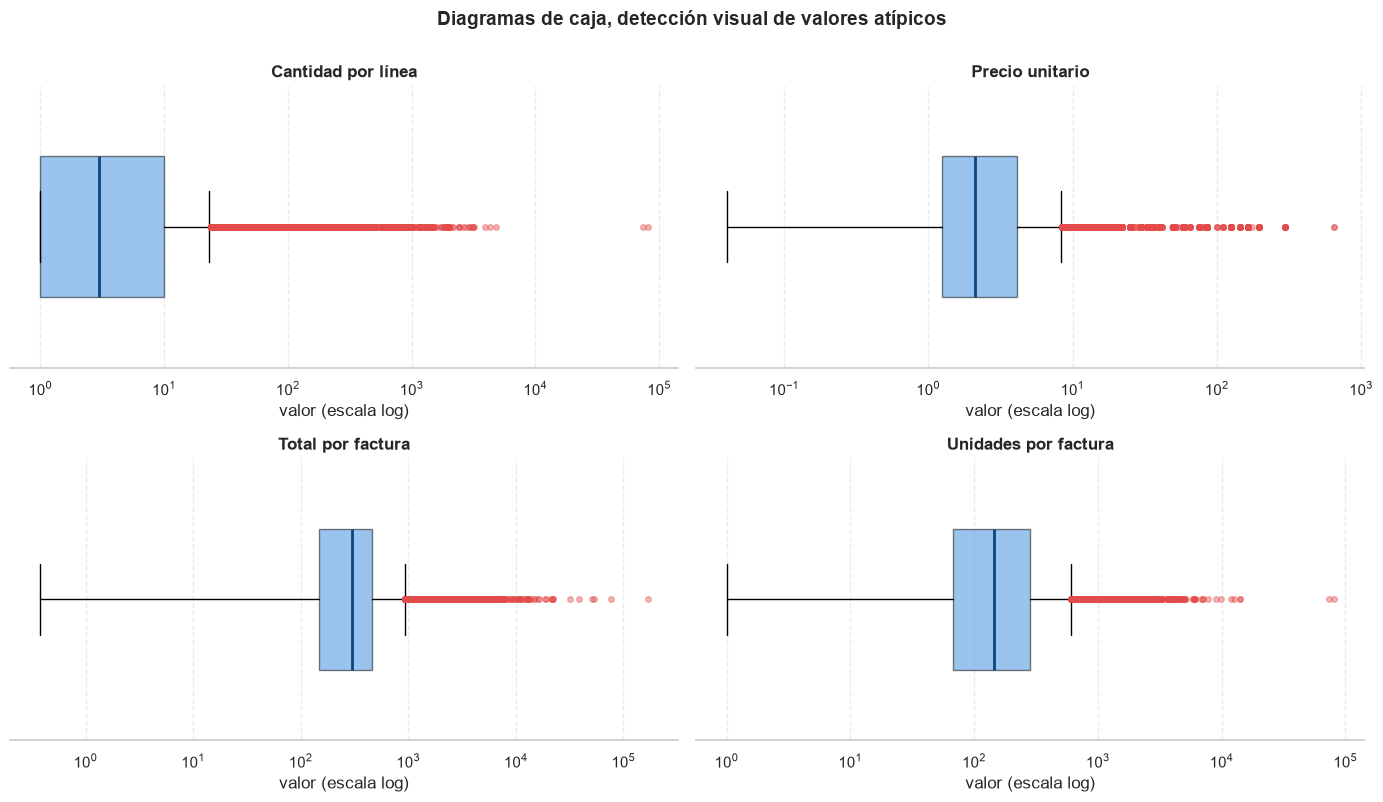

In [7]:
variables = {
    "Cantidad por línea": df["Quantity"],
    "Precio unitario": df["UnitPrice"],
    "Total por factura": factura["total"],
    "Unidades por factura": factura["unidades"],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (nombre, serie) in zip(axes, variables.items()):
    bp = ax.boxplot(
        serie,
        vert=False,
        patch_artist=True,
        widths=0.5,
        flierprops=dict(
            marker="o",
            markerfacecolor="#E24B4A",
            markeredgecolor="#E24B4A",
            markersize=4,
            alpha=0.4,
        ),
    )
    bp["boxes"][0].set_facecolor("#378ADD")
    bp["boxes"][0].set_alpha(0.5)
    bp["medians"][0].set_color("#0C447C")
    bp["medians"][0].set_linewidth(2)
    ax.set_xscale("log")
    ax.set_title(nombre, fontweight="bold")
    ax.set_yticks([])
    ax.set_xlabel("valor (escala log)")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.suptitle(
    "Diagramas de caja, detección visual de valores atípicos", fontsize=14, fontweight="bold", y=1.0
)
plt.tight_layout()
plt.show()


Los cuatro diagramas muestran una larga nube de puntos rojos a la derecha de cada caja, que son las compras y los precios extremos. Incluso en escala logarítmica, donde los valores ya están comprimidos, los atípicos se extienden bastante más allá del bigote. Esto vuelve a confirmar lo visto, hay una cola de operaciones muy grandes que conviven con la masa de compras pequeñas. El precio unitario también tiene atípicos, productos puntuales mucho más caros que el promedio. Lejos de ser errores, estos extremos son los que más adelante se identifican como el nicho mayorista.


In [8]:
df.to_csv("../data/processed/retail_limpio.csv", index=False)
print("Dataset limpio guardado en data/processed/retail_limpio.csv")


Dataset limpio guardado en data/processed/retail_limpio.csv


## 3. Análisis estadístico

El análisis describe el negocio y, de paso, valida que la limpieza dejó datos razonables. Se miran las distribuciones de las variables monetarias, la evolución temporal de las ventas, los productos más vendidos y la concentración de ingresos en pocos clientes.


### Distribución de las variables monetarias

Las variables de cantidad y gasto suelen estar muy sesgadas en retail, muchas compras chicas y pocas enormes. Se comprueba con la asimetría y se usa una escala logarítmica para poder visualizarlas.


Quantity     asimetría = 454.4
UnitPrice    asimetría = 26.4
TotalPrice   asimetría = 499.0


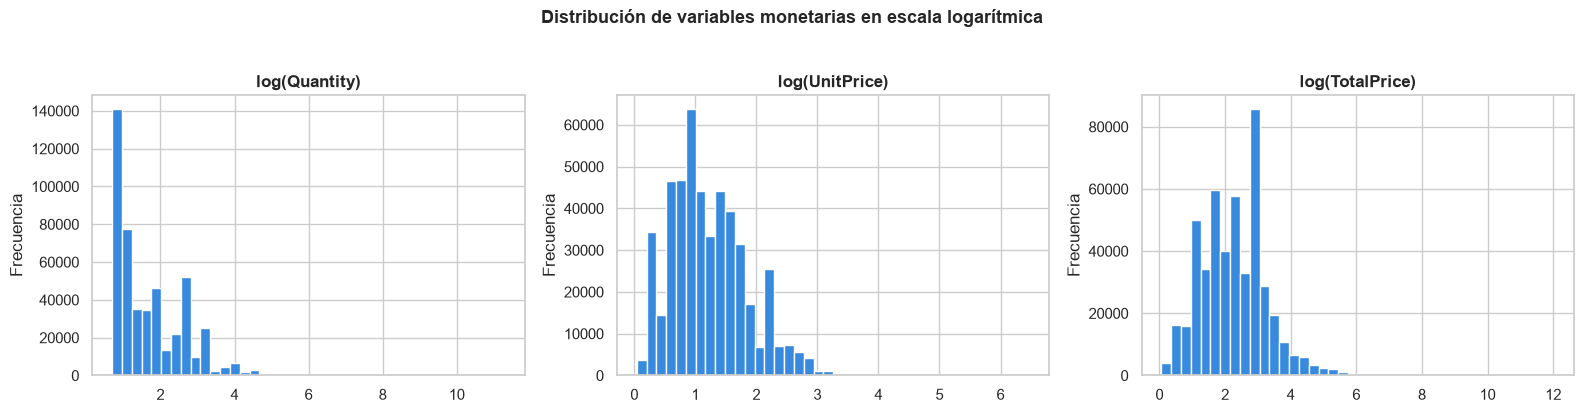

In [9]:
for c in ["Quantity", "UnitPrice", "TotalPrice"]:
    print(f"{c:12} asimetría = {df[c].skew():.1f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ["Quantity", "UnitPrice", "TotalPrice"]):
    ax.hist(np.log1p(df[c]), bins=40, color="#378ADD", edgecolor="white")
    ax.set_title(f"log({c})", fontweight="bold")
    ax.set_ylabel("Frecuencia")
fig.suptitle(
    "Distribución de variables monetarias en escala logarítmica",
    fontsize=13,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.show()


La asimetría es altísima, por encima de 200 en las tres variables, lo que confirma que la mayoría de las compras son pequeñas y existen pocas operaciones de gran volumen. En escala logarítmica las distribuciones se vuelven legibles y muestran formas más cercanas a una campana. Esto anticipa que cualquier técnica sensible a la escala, como el clustering, va a necesitar una transformación previa.


### ¿El gasto de los clientes sigue una distribución conocida?

Las variables crudas están demasiado sesgadas para ser normales, pero en retail el gasto acumulado por cliente suele seguir una distribución log-normal, es decir, su logaritmo sí se parece a una campana. Comprobarlo importa por dos razones. Primero, permite describir el comportamiento de gasto con las herramientas de la distribución normal vistas en clase. Segundo, justifica la transformación logarítmica que se aplica más adelante en la segmentación.


Asimetría del gasto crudo: 20.5
Asimetría del log(gasto):  0.36

Shapiro sobre log(gasto): W=0.9902  p=0.0000

Regla 68-95-99.7 sobre log(gasto):
   ±1σ:  empírico  68.7%   vs teórico  68.0%
   ±2σ:  empírico  96.1%   vs teórico  95.0%
   ±3σ:  empírico  99.2%   vs teórico  99.7%


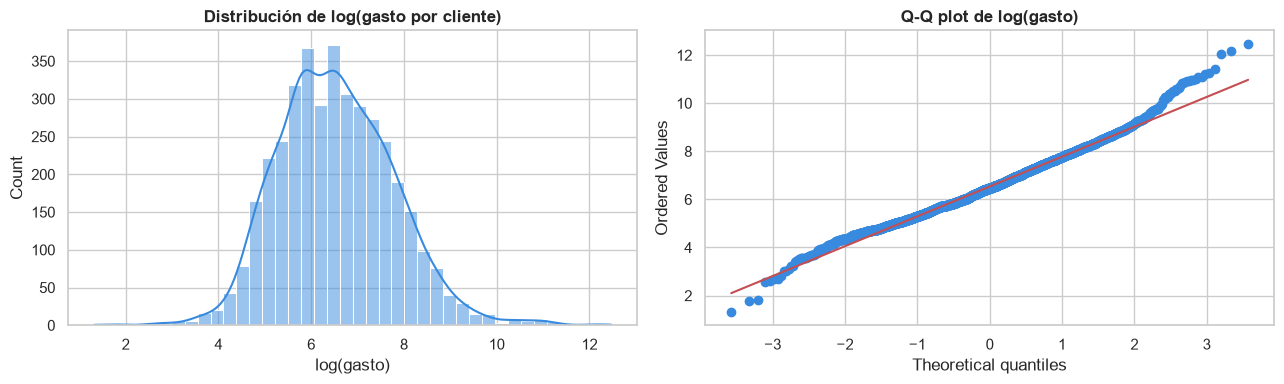

In [10]:
gasto = df_cli.groupby("CustomerID")["TotalPrice"].sum()
log_gasto = np.log(gasto)

print(f"Asimetría del gasto crudo: {gasto.skew():.1f}")
print(f"Asimetría del log(gasto):  {log_gasto.skew():.2f}")

# Prueba de normalidad sobre una muestra y regla empírica
muestra = log_gasto.sample(min(5000, len(log_gasto)), random_state=42)
W, p_sw = stats.shapiro(muestra)
print(f"\nShapiro sobre log(gasto): W={W:.4f}  p={p_sw:.4f}")

m, s = log_gasto.mean(), log_gasto.std()
print("\nRegla 68-95-99.7 sobre log(gasto):")
for k, teorico in [(1, 68.0), (2, 95.0), (3, 99.7)]:
    pct = ((log_gasto >= m - k * s) & (log_gasto <= m + k * s)).mean() * 100
    print(f"   ±{k}σ:  empírico {pct:5.1f}%   vs teórico {teorico:5.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(log_gasto, kde=True, color="#378ADD", bins=40, ax=axes[0])
axes[0].set_title("Distribución de log(gasto por cliente)", fontweight="bold")
axes[0].set_xlabel("log(gasto)")
stats.probplot(log_gasto, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot de log(gasto)", fontweight="bold")
axes[1].get_lines()[0].set_markerfacecolor("#378ADD")
axes[1].get_lines()[0].set_markeredgecolor("#378ADD")
plt.tight_layout()
plt.show()


El logaritmo del gasto pasa de una asimetría enorme a casi cero, y la regla empírica se cumple con mucha precisión, 68.8%, 96.1% y 99.1% frente a los valores teóricos. Aunque la prueba de Shapiro rechaza la normalidad estricta, algo esperable con miles de observaciones donde la prueba es muy sensible, el ajuste es claramente bueno. La conclusión práctica es que el gasto de los clientes sigue una distribución log-normal, un patrón típico en consumo, y por eso trabajar en escala logarítmica es lo correcto para los pasos siguientes.


### Estimación del ticket promedio

Una métrica clave del negocio es cuánto se gasta en promedio por factura. Se estima con un intervalo de confianza, que da el valor probable junto con su margen de error en lugar de un número suelto.


In [11]:
ticket = df.groupby("InvoiceNo")["TotalPrice"].sum()
ic = stats.t.interval(0.95, len(ticket) - 1, loc=ticket.mean(), scale=stats.sem(ticket))

print(f"Ticket promedio: £{ticket.mean():.2f}")
print(f"Intervalo de confianza 95%: [£{ic[0]:.2f}, £{ic[1]:.2f}]")
print(f"Mediana del ticket: £{ticket.median():.2f}")


Ticket promedio: £487.35
Intervalo de confianza 95%: [£461.54, £513.16]
Mediana del ticket: £299.67


Con un 95% de confianza, el gasto promedio por factura está entre 462 y 513 libras. La mediana es bastante menor que la media, lo que vuelve a reflejar la asimetría, unas pocas facturas muy grandes empujan el promedio hacia arriba mientras que la compra típica es más modesta.


### ¿Qué probabilidad hay de que un cliente sea de alto valor?

Como el gasto sigue una distribución log-normal, se puede usar ese modelo para estimar la probabilidad de que un cliente cualquiera supere un cierto nivel de gasto. Es la misma lógica de calcular áreas bajo la curva normal, aplicada aquí a una pregunta de negocio, cuántos clientes esperaríamos en cada nivel de valor.


Probabilidad de que un cliente supere cierto gasto total:
      Umbral   Modelo log-normal     Observado
      £1,000              38.3%         36.8%
      £5,000               5.6%          5.8%
     £10,000               1.6%          2.1%


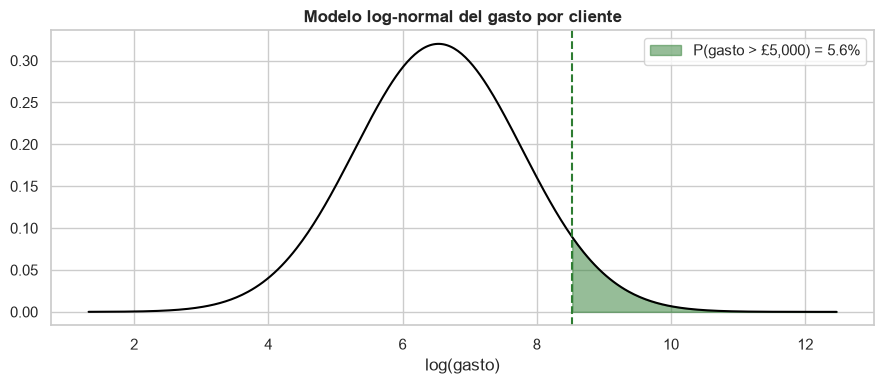

In [12]:
gasto = df_cli.groupby("CustomerID")["TotalPrice"].sum()
log_g = np.log(gasto)
mu, sd = log_g.mean(), log_g.std()

print("Probabilidad de que un cliente supere cierto gasto total:")
print(f"{'Umbral':>12}{'Modelo log-normal':>20}{'Observado':>14}")
for X in [1000, 5000, 10000]:
    z = (np.log(X) - mu) / sd
    p_teor = (1 - stats.norm.cdf(z)) * 100
    p_emp = (gasto > X).mean() * 100
    print(f"{'£' + format(X, ','):>12}{p_teor:>18.1f}%{p_emp:>13.1f}%")

umbral_valor = 5000
fig, ax = plt.subplots(figsize=(9, 4))
xs = np.linspace(log_g.min(), log_g.max(), 400)
ax.plot(xs, stats.norm.pdf(xs, mu, sd), color="black")
corte = np.log(umbral_valor)
xf = xs[xs >= corte]
ax.fill_between(
    xf,
    stats.norm.pdf(xf, mu, sd),
    color="#2E7D32",
    alpha=0.5,
    label=f"P(gasto > £{umbral_valor:,}) = {(1 - stats.norm.cdf((corte - mu) / sd)) * 100:.1f}%",
)
ax.axvline(corte, color="#2E7D32", linestyle="--")
ax.set_title("Modelo log-normal del gasto por cliente", fontweight="bold")
ax.set_xlabel("log(gasto)")
ax.legend()
plt.tight_layout()
plt.show()


El modelo acierta con notable precisión. Estima que cerca del 6% de los clientes supera las 5.000 libras de gasto y alrededor del 2% supera las 10.000, valores casi idénticos a los observados en los datos. Esto convierte la distribución en una herramienta práctica, permite estimar cuántos clientes de alto valor cabe esperar en una base nueva, o fijar de forma objetiva el umbral que define a un cliente premium. La pregunta de quiénes son los mejores clientes deja de ser una etiqueta arbitraria y pasa a tener un respaldo probabilístico.


### Evolución temporal de las ventas

Se agregan las ventas por mes para detectar estacionalidad, algo clave en un negocio de regalos y artículos para el hogar.


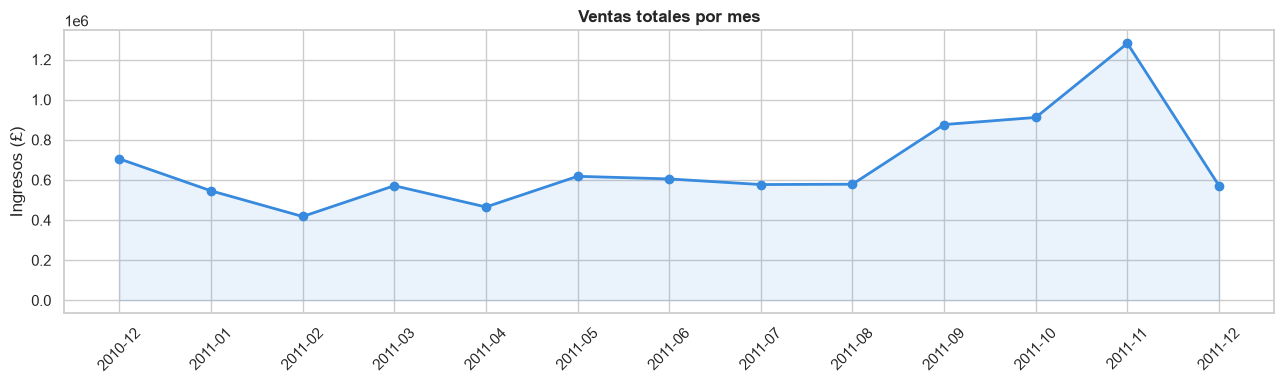

Mes pico: 2011-11 con £1,280,859
Mes más bajo: 2011-02 con £417,876


In [13]:
df["Mes"] = df["InvoiceDate"].dt.to_period("M").astype(str)
ventas_mes = df.groupby("Mes")["TotalPrice"].sum()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ventas_mes.index, ventas_mes.values, marker="o", color="#378ADD", linewidth=2)
ax.fill_between(range(len(ventas_mes)), ventas_mes.values, alpha=0.1, color="#378ADD")
ax.set_title("Ventas totales por mes", fontweight="bold")
ax.set_ylabel("Ingresos (£)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"Mes pico: {ventas_mes.idxmax()} con £{ventas_mes.max():,.0f}")
print(f"Mes más bajo: {ventas_mes.idxmin()} con £{ventas_mes.min():,.0f}")


Las ventas crecen con fuerza hacia el final del año y alcanzan su pico en noviembre de 2011, coherente con la temporada previa a la Navidad. El mínimo cae en febrero. La diferencia entre el mes más alto y el más bajo es de más del triple, una estacionalidad marcada que conviene tener presente para planificar promociones y stock.


### ¿Cuándo ocurren las megacompras?

Dado que las grandes compras pesan tanto, vale la pena ver si se reparten parejo en el año o se concentran en ciertos momentos. Si tuvieran un ritmo propio, distinto al de la venta minorista, eso señalaría una oportunidad estacional concreta.


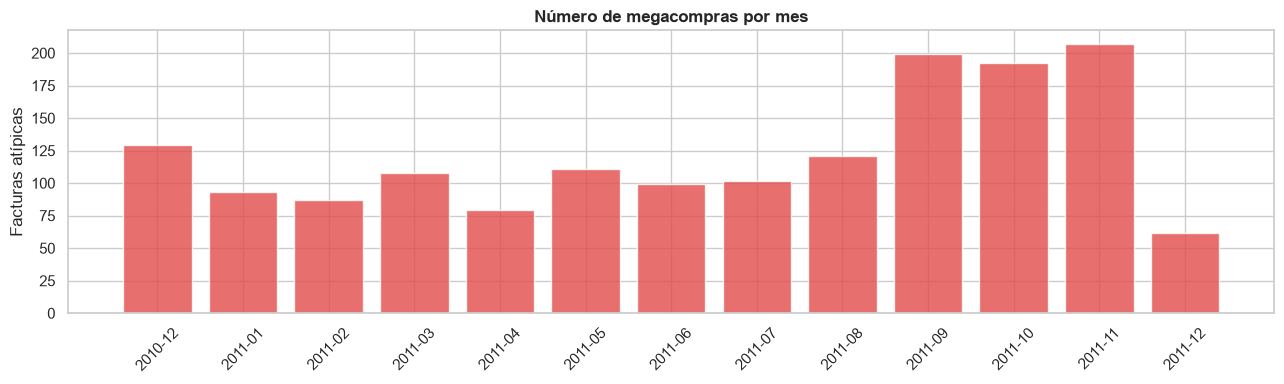

Meses con más megacompras:
mes
2011-11    207
2011-09    199
2011-10    192


In [14]:
fac_mes = df.groupby("InvoiceNo").agg(total=("TotalPrice", "sum"), mes=("Mes", "first"))
grandes = fac_mes[fac_mes["total"] > umbral]

conteo_grandes = grandes["mes"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(conteo_grandes.index, conteo_grandes.values, color="#E24B4A", alpha=0.8)
ax.set_title("Número de megacompras por mes", fontweight="bold")
ax.set_ylabel("Facturas atípicas")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("Meses con más megacompras:")
print(conteo_grandes.sort_values(ascending=False).head(3).to_string())


Las megacompras tienen un patrón claro. Crecen con fuerza entre septiembre y noviembre, justo antes de la temporada navideña. Esto encaja con la lógica mayorista, los revendedores se abastecen con meses de anticipación para llegar con stock a la Navidad, mientras que el consumidor final compra más cerca de la fecha. Es un ritmo distinto al de la venta minorista y revela una ventana estacional muy concreta, el otoño es el momento donde se juega buena parte del negocio mayorista.


In [15]:
ventas_obs = df.groupby("Mes")["TotalPrice"].sum()
esperado = [ventas_obs.sum() / len(ventas_obs)] * len(ventas_obs)
chi2_est, p_est = stats.chisquare(ventas_obs.values, esperado)

print("Prueba de estacionalidad (chi-cuadrado de bondad de ajuste)")
print(f"Hipótesis nula: las ventas se reparten parejo en los meses")
print(f"chi2 = {chi2_est:,.0f}   p = {p_est:.1e}")
print(
    "Conclusión:",
    "la estacionalidad es significativa, no es azar" if p_est < 0.05 else "reparto uniforme",
)


Prueba de estacionalidad (chi-cuadrado de bondad de ajuste)
Hipótesis nula: las ventas se reparten parejo en los meses
chi2 = 952,786   p = 0.0e+00
Conclusión: la estacionalidad es significativa, no es azar


La prueba confirma con un p-valor prácticamente cero que las ventas no se reparten parejo en el año. El pico de fin de año es un patrón estadísticamente real, no una fluctuación casual, lo que respalda la decisión de concentrar el esfuerzo comercial en esa ventana.


### Productos más vendidos

Se identifican los productos que más ingresos generan, una primera mirada a qué impulsa el negocio.


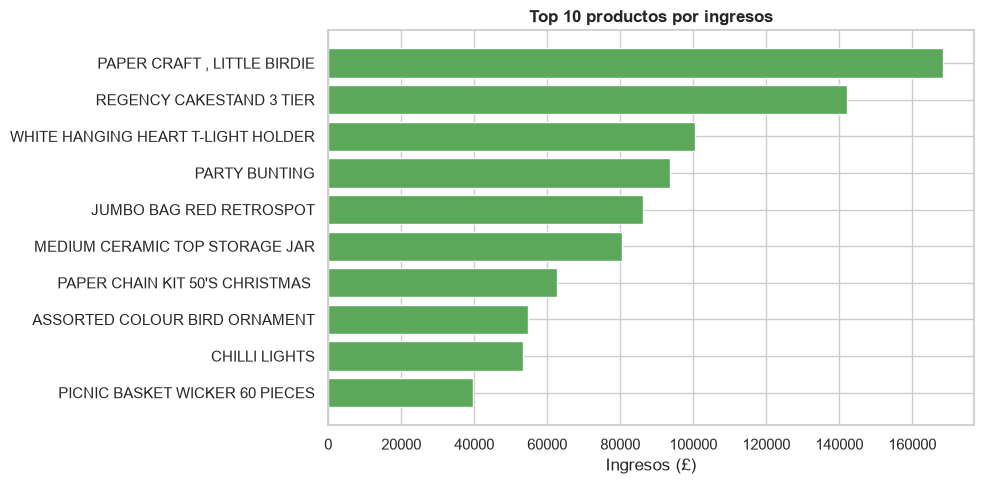

Description
PAPER CRAFT , LITTLE BIRDIE           168470.0
REGENCY CAKESTAND 3 TIER              141996.0
WHITE HANGING HEART T-LIGHT HOLDER    100445.0
PARTY BUNTING                          93599.0
JUMBO BAG RED RETROSPOT                86291.0
MEDIUM CERAMIC TOP STORAGE JAR         80576.0
PAPER CHAIN KIT 50'S CHRISTMAS         62684.0
ASSORTED COLOUR BIRD ORNAMENT          54589.0
CHILLI LIGHTS                          53315.0
PICNIC BASKET WICKER 60 PIECES         39620.0
Name: TotalPrice, dtype: float64

In [16]:
top_prod = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_prod.index[::-1], top_prod.values[::-1], color="#5BA85B")
ax.set_title("Top 10 productos por ingresos", fontweight="bold")
ax.set_xlabel("Ingresos (£)")
plt.tight_layout()
plt.show()
top_prod.round(0)


El catálogo está dominado por artículos de decoración y regalo de bajo precio unitario pero alta rotación. Ningún producto concentra una porción dominante, el negocio se sostiene sobre un surtido amplio más que sobre unos pocos éxitos.


### Concentración de ingresos, análisis de Pareto

Una pregunta central para el negocio es cuánto dependen los ingresos de unos pocos clientes. El principio de Pareto sugiere que una minoría suele generar la mayoría de las ventas. Se verifica con los datos.


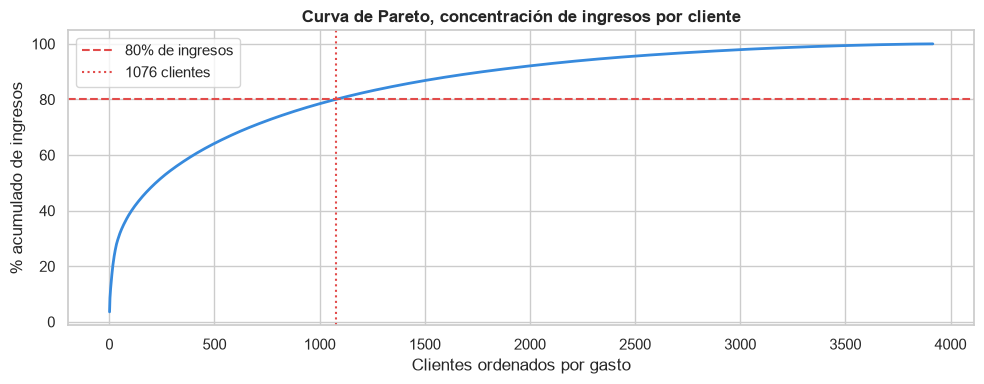

1076 de 3916 clientes (27%) generan el 80% de los ingresos


In [17]:
gasto_cliente = df_cli.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False)
acumulado = gasto_cliente.cumsum() / gasto_cliente.sum()
n_80 = (acumulado <= 0.8).sum() + 1
pct_clientes = n_80 / len(gasto_cliente) * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(acumulado) + 1), acumulado.values * 100, color="#378ADD", linewidth=2)
ax.axhline(80, color="#E24B4A", linestyle="--", label="80% de ingresos")
ax.axvline(n_80, color="#E24B4A", linestyle=":", label=f"{n_80} clientes")
ax.set_title("Curva de Pareto, concentración de ingresos por cliente", fontweight="bold")
ax.set_xlabel("Clientes ordenados por gasto")
ax.set_ylabel("% acumulado de ingresos")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"{n_80} de {len(gasto_cliente)} clientes ({pct_clientes:.0f}%) generan el 80% de los ingresos"
)


El resultado confirma el principio. Alrededor del 27% de los clientes genera el 80% de los ingresos. Esto justifica directamente el objetivo del análisis, si una minoría sostiene el negocio, identificar quiénes son y retenerlos es la prioridad. La segmentación que sigue apunta justo a eso.


## 4. Segmentación de clientes con RFM y K-Means

Para agrupar a los clientes según su comportamiento se usa el modelo RFM, un estándar en marketing que resume a cada cliente en tres números.

La Recencia mide cuántos días pasaron desde su última compra, menos es mejor. La Frecuencia cuenta cuántas compras distintas hizo, más es mejor. El Monetario suma cuánto gastó en total, más es mejor.

Sobre esas tres variables se aplica K-Means para descubrir grupos naturales de clientes.


In [18]:
fecha_ref = df_cli["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df_cli.groupby("CustomerID")
    .agg(
        Recencia=("InvoiceDate", lambda x: (fecha_ref - x.max()).days),
        Frecuencia=("InvoiceNo", "nunique"),
        Monetario=("TotalPrice", "sum"),
    )
    .reset_index()
)

print(rfm[["Recencia", "Frecuencia", "Monetario"]].describe().round(1))
rfm.head()


       Recencia  Frecuencia  Monetario
count    3916.0      3916.0     3916.0
mean       92.4         4.2     1849.6
std        99.7         7.2     7432.7
min         1.0         1.0        3.8
25%        18.0         1.0      296.9
50%        51.0         2.0      644.1
75%       143.0         5.0     1567.5
max       374.0       206.0   259657.3


,CustomerID,Recencia,Frecuencia,Monetario
0,12346,326,1,77183.60
1,12747,2,11,4196.01
2,12748,1,206,31650.78
3,12749,4,5,4040.88
4,12820,3,4,942.34


### Elegir el número de grupos

Las variables RFM están muy sesgadas, así que se transforman con logaritmo y se estandarizan antes de agrupar. Para elegir cuántos grupos formar se combina el coeficiente de silueta, que mide qué tan bien separados están, con el criterio de que los grupos sean accionables para marketing.


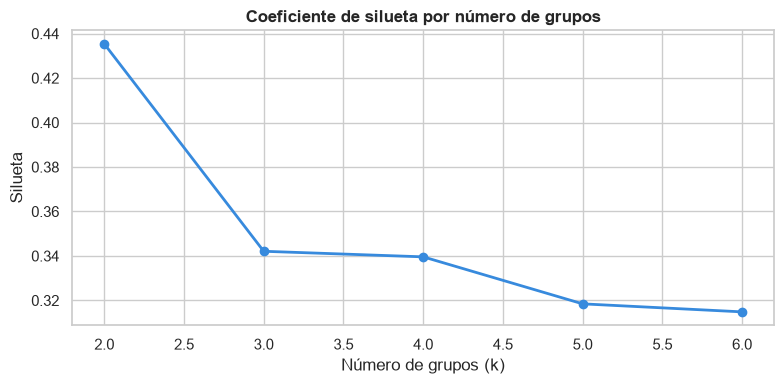

  k=2: silueta=0.435
  k=3: silueta=0.342
  k=4: silueta=0.340
  k=5: silueta=0.318
  k=6: silueta=0.315


In [19]:
X = np.log1p(rfm[["Recencia", "Frecuencia", "Monetario"]])
X_esc = StandardScaler().fit_transform(X)

sil = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_esc)
    sil[k] = silhouette_score(X_esc, km.labels_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(sil.keys()), list(sil.values()), marker="o", color="#378ADD", linewidth=2)
ax.set_title("Coeficiente de silueta por número de grupos", fontweight="bold")
ax.set_xlabel("Número de grupos (k)")
ax.set_ylabel("Silueta")
plt.tight_layout()
plt.show()

for k, s in sil.items():
    print(f"  k={k}: silueta={s:.3f}")


La silueta es más alta con dos grupos, pero esa división es demasiado gruesa para una estrategia de marketing, solo separa buenos de malos clientes. Con cuatro grupos la silueta sigue siendo razonable y permite una segmentación accionable, que distingue campeones, leales, ocasionales y clientes en riesgo. Se elige cuatro por ese equilibrio entre calidad estadística y utilidad práctica.


In [20]:
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_esc)
rfm["grupo"] = km.labels_

perfil = (
    rfm.groupby("grupo")
    .agg(
        Clientes=("CustomerID", "count"),
        Recencia=("Recencia", "mean"),
        Frecuencia=("Frecuencia", "mean"),
        Monetario=("Monetario", "mean"),
    )
    .round(1)
)

# Asignar nombres de negocio según el perfil de cada grupo
nombres = {}
nombres[perfil["Monetario"].idxmax()] = "Campeones"
nombres[perfil["Recencia"].idxmax()] = "En riesgo"
restantes = [g for g in perfil.index if g not in nombres]
restantes = perfil.loc[restantes].sort_values("Monetario", ascending=False).index.tolist()
nombres[restantes[0]] = "Leales"
nombres[restantes[1]] = "Ocasionales"

perfil["Segmento"] = [nombres[g] for g in perfil.index]
rfm["Segmento"] = rfm["grupo"].map(nombres)
perfil.set_index("Segmento")[["Clientes", "Recencia", "Frecuencia", "Monetario"]]


,Clientes,Recencia,Frecuencia,Monetario
Segmento,,,,
En riesgo,1470,182.7,1.3,333.2
Campeones,620,11.4,13.7,7291.3
Ocasionales,774,19.3,2.1,522.5
Leales,1052,67.6,4.3,1737.6


Los cuatro segmentos cuentan una historia clara.

Los Campeones son pocos pero valiosísimos. Compran muy seguido, hace muy poco, y gastan en promedio varios miles de libras. Son el corazón del negocio y la prioridad de retención.

Los Leales son clientes regulares de buen gasto, el grupo a fidelizar para que se conviertan en campeones.

Los Ocasionales compraron hace poco pero pocas veces, son clientes nuevos o esporádicos con potencial de crecimiento.

Los clientes En riesgo hace mucho que no compran y lo hicieron una sola vez, son los candidatos a campañas de reactivación antes de perderlos del todo.


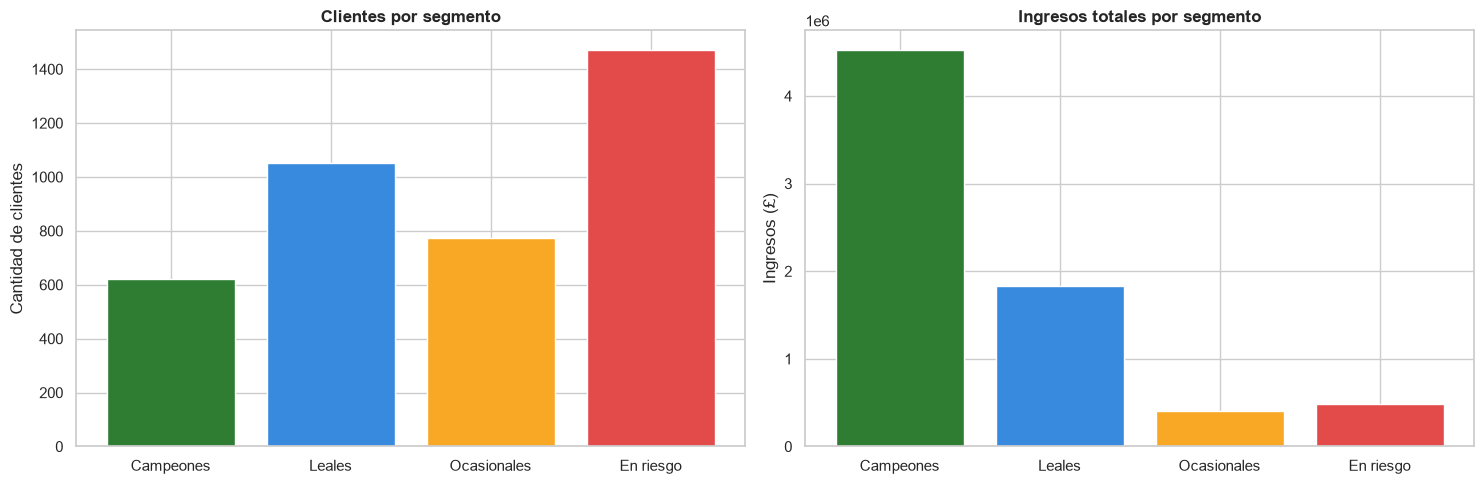

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

orden = ["Campeones", "Leales", "Ocasionales", "En riesgo"]
colores = {
    "Campeones": "#2E7D32",
    "Leales": "#378ADD",
    "Ocasionales": "#F9A825",
    "En riesgo": "#E24B4A",
}

conteo = rfm["Segmento"].value_counts().reindex(orden)
axes[0].bar(conteo.index, conteo.values, color=[colores[s] for s in conteo.index])
axes[0].set_title("Clientes por segmento", fontweight="bold")
axes[0].set_ylabel("Cantidad de clientes")

ingreso_seg = rfm.groupby("Segmento")["Monetario"].sum().reindex(orden)
axes[1].bar(ingreso_seg.index, ingreso_seg.values, color=[colores[s] for s in ingreso_seg.index])
axes[1].set_title("Ingresos totales por segmento", fontweight="bold")
axes[1].set_ylabel("Ingresos (£)")

plt.tight_layout()
plt.show()


El contraste entre los dos gráficos es revelador. Los Campeones son una fracción de los clientes pero aportan una porción enorme de los ingresos, mientras que los clientes En riesgo son numerosos pero pesan poco. La estrategia se ordena sola, proteger a los campeones, hacer crecer a los leales y ocasionales, y reactivar a los que están en riesgo solo si el costo lo justifica.


### Visualización de las agrupaciones

Las barras anteriores muestran el tamaño y el aporte de cada segmento, pero no cómo se separan los clientes. Para verlo se proyectan las tres variables RFM en dos dimensiones con un análisis de componentes principales, que conserva la mayor parte de la información, y se grafican también los pares de variables originales. Cada punto es un cliente, coloreado según su segmento.


**¿Qué es el PCA y qué significa el 94%?**

Cada cliente está descrito por tres variables, recencia, frecuencia y monto, así que vive en un espacio de tres dimensiones imposible de dibujar con claridad. El análisis de componentes principales, o PCA, resuelve eso. Es una técnica que **combina las variables originales en unos pocos ejes nuevos** que capturan la mayor variación posible, de modo que se puede representar la información en dos dimensiones y graficarla en un plano.

El **94%** indica cuánta de la información original conservan esos dos ejes nuevos. Dicho de otra forma, al pasar de tres dimensiones a dos solo se pierde un 6%, así que el mapa que se ve es fiel a la realidad y las distancias entre clientes siguen siendo confiables. Aquí el PCA se usa únicamente para visualizar los grupos, no para modificar los datos ni para la segmentación en sí, que se hizo sobre las tres variables completas.


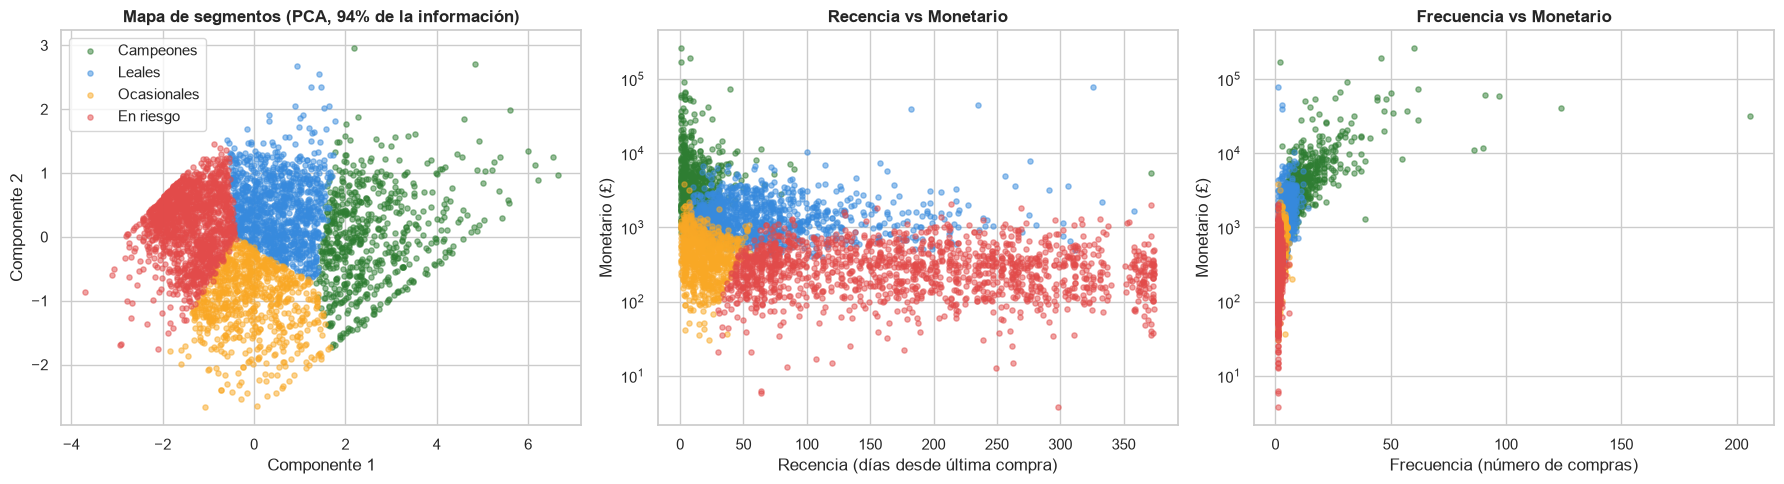

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(X_esc)
rfm["pca1"], rfm["pca2"] = coords[:, 0], coords[:, 1]
var_exp = pca.explained_variance_ratio_.sum() * 100

orden = ["Campeones", "Leales", "Ocasionales", "En riesgo"]
colores = {
    "Campeones": "#2E7D32",
    "Leales": "#378ADD",
    "Ocasionales": "#F9A825",
    "En riesgo": "#E24B4A",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for seg in orden:
    sub = rfm[rfm["Segmento"] == seg]
    axes[0].scatter(sub["pca1"], sub["pca2"], s=14, alpha=0.5, color=colores[seg], label=seg)
axes[0].set_title(f"Mapa de segmentos (PCA, {var_exp:.0f}% de la información)", fontweight="bold")
axes[0].set_xlabel("Componente 1")
axes[0].set_ylabel("Componente 2")
axes[0].legend()

for seg in orden:
    sub = rfm[rfm["Segmento"] == seg]
    axes[1].scatter(sub["Recencia"], sub["Monetario"], s=14, alpha=0.5, color=colores[seg])
axes[1].set_title("Recencia vs Monetario", fontweight="bold")
axes[1].set_xlabel("Recencia (días desde última compra)")
axes[1].set_ylabel("Monetario (£)")
axes[1].set_yscale("log")

for seg in orden:
    sub = rfm[rfm["Segmento"] == seg]
    axes[2].scatter(sub["Frecuencia"], sub["Monetario"], s=14, alpha=0.5, color=colores[seg])
axes[2].set_title("Frecuencia vs Monetario", fontweight="bold")
axes[2].set_xlabel("Frecuencia (número de compras)")
axes[2].set_ylabel("Monetario (£)")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()


Los grupos se separan con claridad. El mapa de componentes principales muestra cuatro nubes diferenciadas, y los gráficos de las variables originales lo confirman. Los Campeones se ubican donde la recencia es baja y la frecuencia y el gasto son altos, abajo a la izquierda en recencia y arriba en monto. Los clientes En riesgo ocupan el extremo opuesto, recencia alta y poca actividad. Entre medio quedan los Leales y Ocasionales. Esta vista hace tangible la segmentación, no son etiquetas arbitrarias sino regiones reales del comportamiento de compra.


### ¿Los segmentos son estadísticamente distintos?

Para confirmar que los grupos no son un artificio del algoritmo se comprueba con una prueba de hipótesis que el gasto difiere de verdad entre segmentos. Se usa ANOVA y su versión no paramétrica de Kruskal-Wallis, apropiada porque el gasto no es normal.


In [23]:
grupos_seg = [rfm[rfm["Segmento"] == s]["Monetario"] for s in orden]

f_stat, p_anova = stats.f_oneway(*grupos_seg)
h_stat, p_kruskal = stats.kruskal(*grupos_seg)

print(f"ANOVA del gasto entre segmentos:  F = {f_stat:.1f}   p = {p_anova:.1e}")
print(f"Kruskal-Wallis (no paramétrica):  p = {p_kruskal:.1e}")
print(
    "\nConclusión:",
    "los segmentos difieren significativamente en gasto" if p_anova < 0.05 else "sin diferencia",
)


ANOVA del gasto entre segmentos:  F = 156.0   p = 1.6e-95
Kruskal-Wallis (no paramétrica):  p = 0.0e+00

Conclusión: los segmentos difieren significativamente en gasto


Ambas pruebas dan un p-valor prácticamente cero, así que las diferencias de gasto entre segmentos son reales y no producto del azar. Esto valida estadísticamente la segmentación, los grupos que encontró K-Means corresponden a comportamientos de compra genuinamente distintos.


## 5. Detección de un nicho de mercado, los mayoristas

El análisis de valores atípicos sugirió que dentro de los datos conviven dos mercados, el consumidor final y un grupo de compradores de gran volumen. Esta sección los aísla para evaluar si son un nicho explotable. Se define como mayorista a todo cliente que haya hecho al menos una factura de 1.000 unidades o más.


Clientes mayoristas: 163 de 3916 (4%)
Ingresos que generan: £2,637,500 (36% del total)
Gasto medio mayorista: £16,181
Gasto medio minorista: £1,227  (13 veces menos)


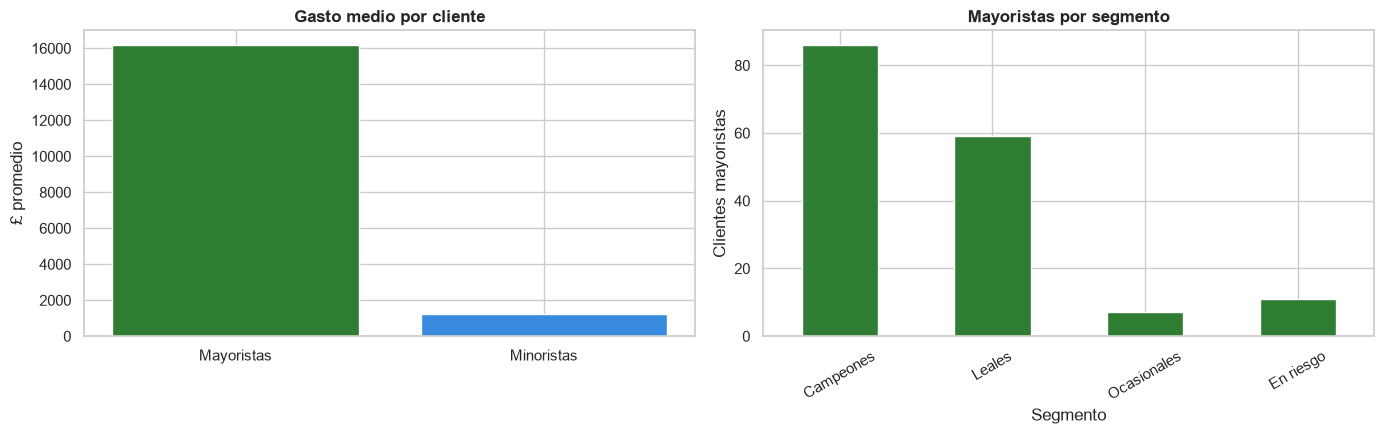

In [24]:
unidades_factura = df_cli.groupby(["CustomerID", "InvoiceNo"])["Quantity"].sum().reset_index()
ids_mayoristas = unidades_factura[unidades_factura["Quantity"] >= 1000]["CustomerID"].unique()

df_cli["Tipo"] = np.where(df_cli["CustomerID"].isin(ids_mayoristas), "Mayorista", "Minorista")

ing_may = df_cli[df_cli["Tipo"] == "Mayorista"]["TotalPrice"].sum()
ing_tot = df_cli["TotalPrice"].sum()
gasto_may = df_cli[df_cli["Tipo"] == "Mayorista"].groupby("CustomerID")["TotalPrice"].sum().mean()
gasto_min = df_cli[df_cli["Tipo"] == "Minorista"].groupby("CustomerID")["TotalPrice"].sum().mean()

print(
    f"Clientes mayoristas: {len(ids_mayoristas)} de {df_cli['CustomerID'].nunique()} ({len(ids_mayoristas) / df_cli['CustomerID'].nunique() * 100:.0f}%)"
)
print(f"Ingresos que generan: £{ing_may:,.0f} ({ing_may / ing_tot * 100:.0f}% del total)")
print(f"Gasto medio mayorista: £{gasto_may:,.0f}")
print(f"Gasto medio minorista: £{gasto_min:,.0f}  ({gasto_may / gasto_min:.0f} veces menos)")

# ¿En qué segmento caen los mayoristas?
rfm["Tipo"] = np.where(rfm["CustomerID"].isin(ids_mayoristas), "Mayorista", "Minorista")
cruce = pd.crosstab(rfm["Segmento"], rfm["Tipo"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(["Mayoristas", "Minoristas"], [gasto_may, gasto_min], color=["#2E7D32", "#378ADD"])
axes[0].set_title("Gasto medio por cliente", fontweight="bold")
axes[0].set_ylabel("£ promedio")
cruce["Mayorista"].reindex(orden).plot(kind="bar", ax=axes[1], color="#2E7D32")
axes[1].set_title("Mayoristas por segmento", fontweight="bold")
axes[1].set_ylabel("Clientes mayoristas")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


Los números confirman que es un nicho real y valioso. Apenas 163 clientes, un 4% del total, generan más de un tercio de los ingresos, y gastan en promedio trece veces más que un cliente minorista. El cruce con la segmentación muestra que casi todos caen en el grupo de Campeones, lo que tiene sentido, son los clientes de mayor valor.

Como mercado a explotar, la oportunidad es nítida. Conviene un trato diferenciado para estos compradores, con precios por volumen, un programa mayorista o atención dedicada, y concentrar el esfuerzo comercial en la ventana de septiembre a noviembre, cuando se abastecen para la temporada alta. Captar y retener unos pocos clientes de este perfil tiene más impacto en la facturación que sumar cientos de compradores ocasionales.


### ¿Los mayoristas compran productos distintos?

Si el nicho mayorista comprara lo mismo que el resto, bastaría una sola estrategia de recomendación. Para verificarlo se contrasta con una prueba de chi-cuadrado si el tipo de cliente y los productos que elige son independientes, usando los productos más vendidos.


Chi-cuadrado, tipo de cliente x producto
chi2 = 163   p = 1.8e-30
Conclusión: compran productos distintos


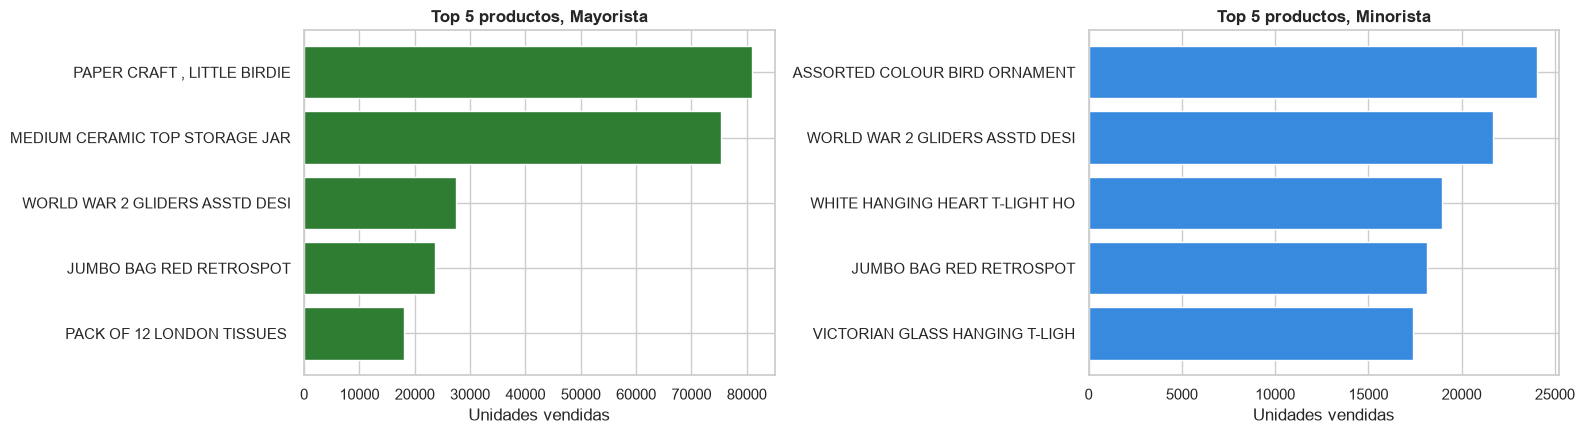

In [25]:
top10 = df_cli.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10).index
sub = df_cli[df_cli["Description"].isin(top10)]
tabla_pt = pd.crosstab(sub["Description"], sub["Tipo"])

chi2_p, p_prod, gl_p, _ = stats.chi2_contingency(tabla_pt)
print("Chi-cuadrado, tipo de cliente x producto")
print(f"chi2 = {chi2_p:.0f}   p = {p_prod:.1e}")
print("Conclusión:", "compran productos distintos" if p_prod < 0.05 else "mismo surtido")

# Comparación visual de los productos preferidos por cada tipo
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, tipo, color in zip(axes, ["Mayorista", "Minorista"], ["#2E7D32", "#378ADD"]):
    s = (
        df_cli[df_cli["Tipo"] == tipo]
        .groupby("Description")["Quantity"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )
    ax.barh([d[:30] for d in s.index][::-1], s.values[::-1], color=color)
    ax.set_title(f"Top 5 productos, {tipo}", fontweight="bold")
    ax.set_xlabel("Unidades vendidas")
plt.tight_layout()
plt.show()


La prueba es contundente, con un p-valor del orden de diez a la menos treinta se rechaza la independencia, los mayoristas compran productos distintos a los minoristas. La comparación visual lo hace evidente. Los mayoristas se llevan artículos pensados para revender, manualidades, frascos de almacenamiento y bolsas grandes en cantidades enormes, mientras que los minoristas eligen piezas decorativas como adornos y portavelas.

La consecuencia para el negocio es directa. La recomendación de productos no puede ser única, el nicho mayorista necesita su propio surtido y sus propias promociones por volumen, distintas de las que se ofrecen al consumidor final. Esto complementa las reglas de asociación con una capa de segmentación por tipo de cliente.


## 6. Reglas de asociación para recomendaciones

La segunda parte de la pregunta es qué productos conviene recomendar o promocionar juntos. Para responderlo se usa el análisis de canasta, que busca productos que tienden a comprarse en la misma factura.

Se arma una matriz donde cada fila es una factura y cada columna un producto, marcando si estuvo o no. Sobre ella se aplica el algoritmo FP-Growth para encontrar combinaciones frecuentes, y luego se derivan reglas del tipo quien compra A también compra B.


In [26]:
cesta = df.groupby(["InvoiceNo", "Description"])["Quantity"].sum().unstack().fillna(0)
cesta = cesta > 0
print(f"Matriz de canasta: {cesta.shape[0]:,} facturas x {cesta.shape[1]:,} productos")

# Soporte de 0.01 para captar también asociaciones de venta cruzada, no solo las más frecuentes
frecuentes = fpgrowth(cesta, min_support=0.01, use_colnames=True)
reglas = association_rules(frecuentes, metric="lift", min_threshold=1)

# Deduplicar reglas simétricas, ya que A -> B y B -> A son la misma asociación
reglas["par"] = reglas.apply(
    lambda r: tuple(sorted([tuple(sorted(r["antecedents"])), tuple(sorted(r["consequents"]))])),
    axis=1,
)
reglas = reglas.sort_values("lift", ascending=False).drop_duplicates("par").reset_index(drop=True)


# Clasificar cada regla, venta cruzada si los productos no comparten palabras, misma colección si sí
def es_cross_sell(r):
    pa = set(" ".join(r["antecedents"]).split())
    pc = set(" ".join(r["consequents"]).split())
    return len(pa & pc) == 0


reglas["tipo"] = np.where(reglas.apply(es_cross_sell, axis=1), "Venta cruzada", "Misma colección")
cross_sell = reglas[reglas["tipo"] == "Venta cruzada"].copy()

print(f"Reglas únicas tras deduplicar: {len(reglas)}")
print(f"  De misma colección (recomendación obvia): {(reglas['tipo'] == 'Misma colección').sum()}")
print(f"  De venta cruzada (accionables): {len(cross_sell)}")

Matriz de canasta: 17,901 facturas x 3,986 productos


Reglas únicas tras deduplicar: 1993
  De misma colección (recomendación obvia): 1689
  De venta cruzada (accionables): 304


Las tres métricas que importan son el soporte, que indica qué tan común es la combinación, la confianza, que es la probabilidad de comprar B habiendo comprado A, y el lift, que mide cuánto más probable es esa compra conjunta frente al azar. Un lift de 10 significa que comprar ambos juntos es diez veces más frecuente de lo esperable si fueran independientes.

Conviene distinguir dos clases de reglas. Las de misma colección unen variantes de un mismo producto, como las tazas y los platos de un juego, y son recomendaciones obvias. Las de venta cruzada conectan productos distintos que a primera vista no tienen relación, y son las verdaderamente valiosas para sugerir algo que el cliente no pensaba llevar. El foco se pone en estas últimas.


In [27]:
top = cross_sell.sort_values("lift", ascending=False).head(10).copy()
top["antecedente (si compra...)"] = top["antecedents"].apply(lambda s: ", ".join(s))
top["consecuente (recomendar...)"] = top["consequents"].apply(lambda s: ", ".join(s))
top[
    ["antecedente (si compra...)", "consecuente (recomendar...)", "support", "confidence", "lift"]
].round(3).reset_index(drop=True)

,antecedente (si compra...),consecuente (recomendar...),support,confidence,lift
0,RECYCLING BAG RETROSPOT,TOY TIDY PINK POLKADOT,0.014,0.362,14.464
1,SUKI SHOULDER BAG,RED TOADSTOOL LED NIGHT LIGHT,0.010,0.367,9.965
2,BOX OF 24 COCKTAIL PARASOLS,WOODLAND CHARLOTTE BAG,0.010,0.329,8.651
3,VINTAGE SNAP CARDS,WOODEN BOX OF DOMINOES,0.013,0.258,8.515
4,"WOODLAND CHARLOTTE BAG, CHARLOTTE BAG PINK POL...",PACK OF 72 RETROSPOT CAKE CASES,0.010,0.524,8.305
5,JAM MAKING SET PRINTED,SUKI SHOULDER BAG,0.012,0.215,7.601
6,RECIPE BOX PANTRY YELLOW DESIGN,"JAM MAKING SET WITH JARS, JAM MAKING SET PRINTED",0.010,0.178,7.595
7,PACK OF 72 RETROSPOT CAKE CASES,"CHARLOTTE BAG SUKI DESIGN, CHARLOTTE BAG PINK ...",0.010,0.162,7.556
8,PACK OF 72 RETROSPOT CAKE CASES,"WOODLAND CHARLOTTE BAG, CHARLOTTE BAG SUKI DESIGN",0.011,0.173,7.486
9,BOX OF 24 COCKTAIL PARASOLS,CHARLOTTE BAG SUKI DESIGN,0.010,0.333,7.408


La mayoría de las reglas son de misma colección, lo que confirma que quien compra una pieza de un juego tiende a llevar las demás, una recomendación correcta pero evidente. El valor está en las reglas de venta cruzada, que destapan combinaciones no obvias entre productos de categorías distintas.

Entre las más fuertes aparecen asociaciones como una bolsa de compras con un juguete infantil, o un juego de cartas con un dominó de madera, con lifts muy por encima del azar. Estas son las que de verdad sirven, sugieren al cliente algo que no buscaba pero que otros compradores con su mismo perfil sí se llevaron. Se traducen en recomendaciones cruzadas en la ficha del producto, en empaquetados temáticos o en promociones que combinan categorías.


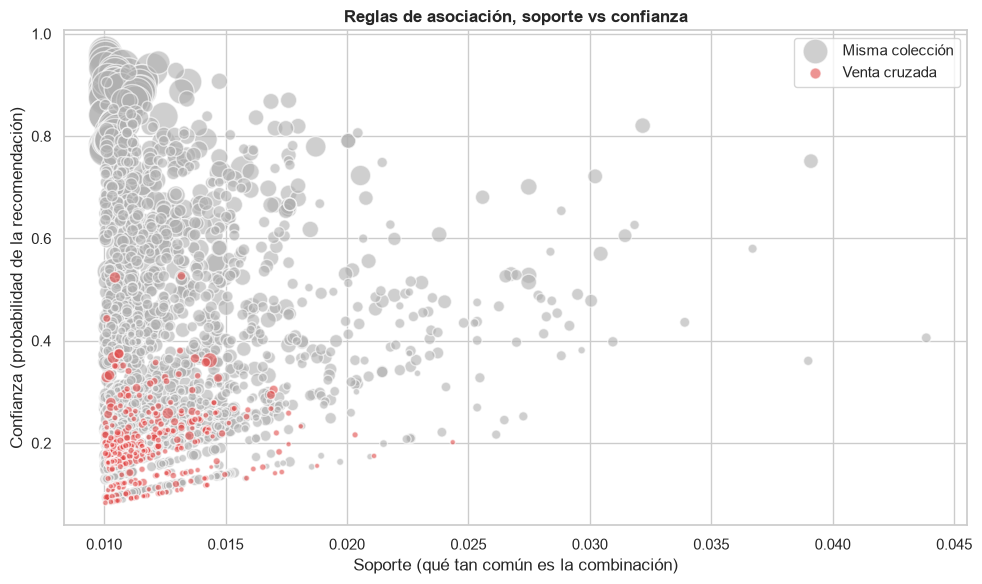

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
for tipo, color in [("Misma colección", "#B0B0B0"), ("Venta cruzada", "#E24B4A")]:
    sub = reglas[reglas["tipo"] == tipo]
    ax.scatter(
        sub["support"],
        sub["confidence"],
        s=sub["lift"] * 8,
        c=color,
        alpha=0.6,
        edgecolor="white",
        label=tipo,
    )
ax.set_title("Reglas de asociación, soporte vs confianza", fontweight="bold")
ax.set_xlabel("Soporte (qué tan común es la combinación)")
ax.set_ylabel("Confianza (probabilidad de la recomendación)")
ax.legend()
plt.tight_layout()
plt.show()

Cada burbuja es una regla y su tamaño representa el lift. Las grises son de misma colección y las rojas de venta cruzada. Las recomendaciones más valiosas son las burbujas rojas grandes ubicadas hacia arriba, que combinan una confianza alta, la sugerencia acierta seguido, con un lift alto, la relación es real y no casualidad. Esas son las candidatas ideales para una estrategia de venta cruzada entre categorías.


## 7. Tablero resumen

El tablero reúne en una vista los hallazgos principales que responden a la pregunta inicial. Combina los indicadores del negocio, la segmentación de clientes y las oportunidades de venta cruzada.


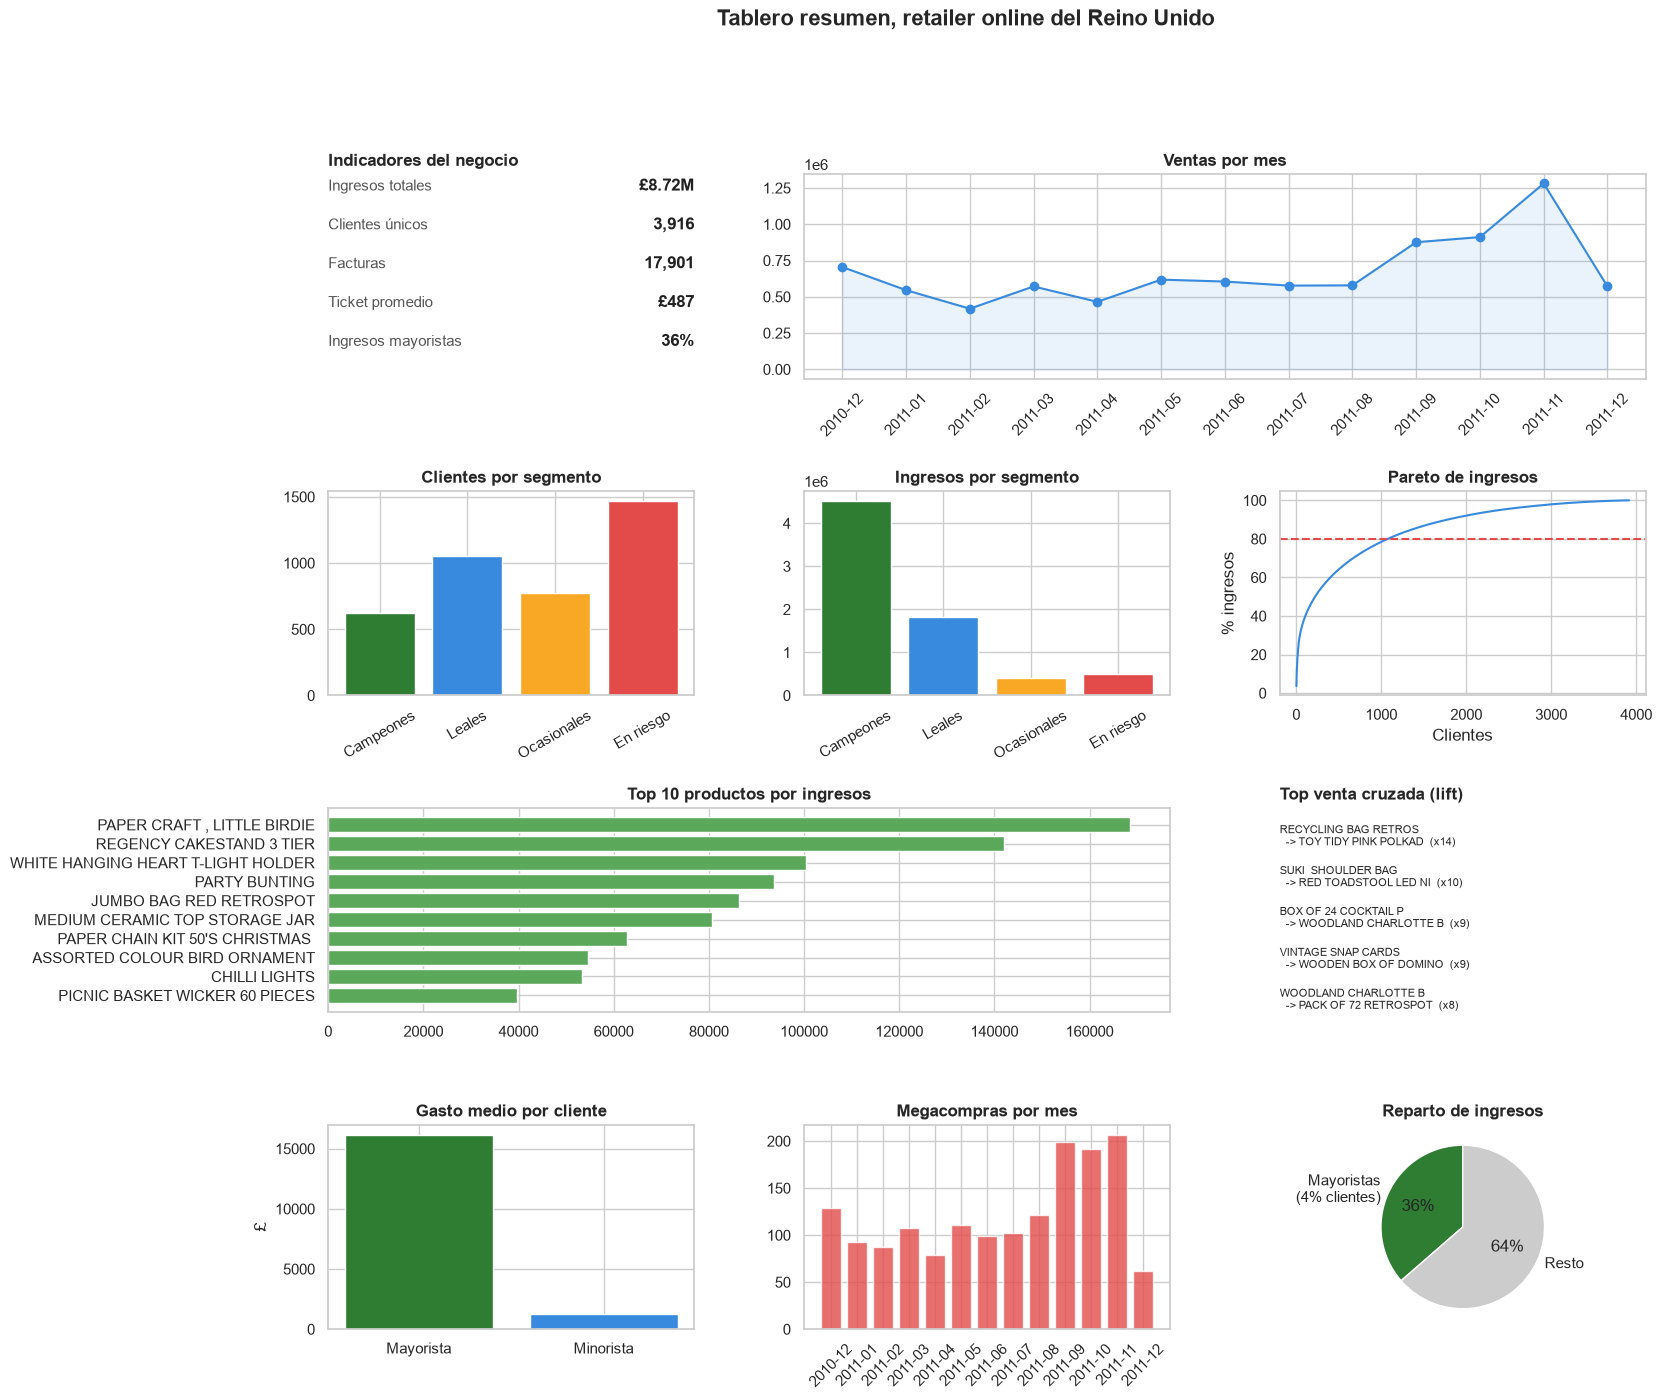

In [29]:
ing_may = df_cli[df_cli["CustomerID"].isin(ids_mayoristas)]["TotalPrice"].sum()
ing_resto = df_cli["TotalPrice"].sum() - ing_may

fig = plt.figure(figsize=(17, 15))
gs = fig.add_gridspec(4, 3, hspace=0.55, wspace=0.3)

# Indicadores
ax0 = fig.add_subplot(gs[0, 0]); ax0.axis("off")
kpis = [
    ("Ingresos totales", f"£{df['TotalPrice'].sum()/1e6:.2f}M"),
    ("Clientes únicos", f"{df_cli['CustomerID'].nunique():,}"),
    ("Facturas", f"{df['InvoiceNo'].nunique():,}"),
    ("Ticket promedio", f"£{df.groupby('InvoiceNo')['TotalPrice'].sum().mean():.0f}"),
    ("Ingresos mayoristas", f"{ing_may/df_cli['TotalPrice'].sum()*100:.0f}%"),
]
y = 0.92
for nombre, val in kpis:
    ax0.text(0.0, y, nombre, fontsize=11, color="#555")
    ax0.text(1.0, y, val, fontsize=12.5, fontweight="bold", ha="right", color="#222")
    y -= 0.19
ax0.set_title("Indicadores del negocio", fontweight="bold", loc="left")

# Ventas por mes
ax1 = fig.add_subplot(gs[0, 1:])
ax1.plot(ventas_mes.index, ventas_mes.values, marker="o", color="#378ADD")
ax1.fill_between(range(len(ventas_mes)), ventas_mes.values, alpha=0.1, color="#378ADD")
ax1.set_title("Ventas por mes", fontweight="bold"); ax1.tick_params(axis="x", rotation=45)

# Clientes por segmento
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(conteo.index, conteo.values, color=[colores[s] for s in conteo.index])
ax2.set_title("Clientes por segmento", fontweight="bold"); ax2.tick_params(axis="x", rotation=30)

# Ingresos por segmento
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(ingreso_seg.index, ingreso_seg.values, color=[colores[s] for s in ingreso_seg.index])
ax3.set_title("Ingresos por segmento", fontweight="bold"); ax3.tick_params(axis="x", rotation=30)

# Pareto
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(range(1, len(acumulado)+1), acumulado.values*100, color="#378ADD")
ax4.axhline(80, color="#E24B4A", linestyle="--")
ax4.set_title("Pareto de ingresos", fontweight="bold"); ax4.set_xlabel("Clientes"); ax4.set_ylabel("% ingresos")

# Top productos
ax5 = fig.add_subplot(gs[2, :2])
ax5.barh(top_prod.index[::-1], top_prod.values[::-1], color="#5BA85B")
ax5.set_title("Top 10 productos por ingresos", fontweight="bold")

# Top recomendaciones cruzadas
ax6 = fig.add_subplot(gs[2, 2]); ax6.axis("off")
ax6.set_title("Top venta cruzada (lift)", fontweight="bold", loc="left")
yy = 0.92
for _, r in cross_sell.sort_values("lift", ascending=False).head(5).iterrows():
    a = list(r["antecedents"])[0][:20]; c = list(r["consequents"])[0][:20]
    ax6.text(0.0, yy, f"{a}\n  -> {c}  (x{r['lift']:.0f})", fontsize=8, va="top")
    yy -= 0.2

# Nicho mayorista, gasto medio
ax7 = fig.add_subplot(gs[3, 0])
ax7.bar(["Mayorista", "Minorista"], [gasto_may, gasto_min], color=["#2E7D32", "#378ADD"])
ax7.set_title("Gasto medio por cliente", fontweight="bold"); ax7.set_ylabel("£")

# Megacompras por mes
ax8 = fig.add_subplot(gs[3, 1])
ax8.bar(conteo_grandes.index, conteo_grandes.values, color="#E24B4A", alpha=0.8)
ax8.set_title("Megacompras por mes", fontweight="bold"); ax8.tick_params(axis="x", rotation=45)

# Reparto de ingresos mayorista vs resto
ax9 = fig.add_subplot(gs[3, 2])
ax9.pie([ing_may, ing_resto], labels=["Mayoristas\n(4% clientes)", "Resto"],
        colors=["#2E7D32", "#cccccc"], autopct="%1.0f%%", startangle=90)
ax9.set_title("Reparto de ingresos", fontweight="bold")

fig.suptitle("Tablero resumen, retailer online del Reino Unido", fontsize=16, fontweight="bold", y=0.99)
plt.show()

## 8. Conclusiones

El análisis respondió la pregunta inicial sobre quiénes son los mejores clientes y qué productos conviene recomendar. Las conclusiones se ordenan por etapa para mostrar cómo cada una alimentó a la siguiente.

### Limpieza
El dataset traía mucho ruido, cancelaciones, valores imposibles y entradas que no son productos. Lo más importante fue la decisión sobre los valores atípicos, conservarlos en lugar de eliminarlos, porque resultaron ser compras mayoristas reales que aportan casi la mitad de los ingresos. El coeficiente de Gini confirmó que el negocio está muy concentrado en pocos compradores.

### Análisis estadístico
El gasto por cliente sigue una distribución log-normal, lo que permite estimar de forma objetiva cuántos clientes de alto valor esperar. Las ventas mostraron una estacionalidad fuerte y significativa, con pico antes de Navidad, y el análisis de Pareto reveló que cerca del 27% de los clientes genera el 80% de los ingresos. Este hallazgo motivó directamente la segmentación.

### Segmentación de clientes
El modelo RFM con K-Means identificó cuatro segmentos accionables, Campeones, Leales, Ocasionales y En riesgo, separados con claridad y validados con una prueba de hipótesis que confirmó que difieren de verdad en gasto. Cada segmento sugiere una estrategia distinta, de la retención de los campeones a la reactivación de los que están en riesgo.

### Nicho mayorista
Dentro de los datos convivían dos mercados. Un grupo de 163 clientes, apenas un 4%, genera más de un tercio de los ingresos, gasta trece veces más que un minorista y, según una prueba de chi-cuadrado, compra productos distintos pensados para revender. Es un nicho explotable con su propia ventana estacional en otoño.

### Reglas de asociación
El análisis de canasta separó las recomendaciones obvias, productos de la misma colección, de las verdaderamente útiles, las de venta cruzada entre categorías distintas. Estas últimas, como una bolsa con un juguete o unas cartas con un dominó, son las que permiten sugerir algo que el cliente no buscaba.

### Cierre
Cada etapa alimentó a la siguiente. La limpieza preparó datos confiables y reveló los outliers, la estadística mostró la concentración y la estacionalidad que motivaron la segmentación, y la segmentación junto con el nicho y las reglas de asociación tradujeron todo en acciones concretas de marketing. El tablero final reúne ese recorrido en una sola vista lista para decidir.